# Lab №1
## Robot Perception course

You ( A brave robotics engineer) want to estimate the radius of the robot wheel during the motion. You remember from physics  $$v = Rw$$ where $v$ is the linear velocity, $R$ is the radius of the wheel, and $w$ is the angular velocity of the wheel. <br>
Using the accelerometer and encoder, you have obtained the following data:

| Angular velocity (w) | Linear velocity (v) |
|-------------|-------------|
| 0.2         | 1.23        |
| 0.3         | 1.38        |
| 0.4         | 2.06        |
| 0.5         | 2.47        |
| 0.6         | 3.17        |

Your task:
1. Draw a line through the origin (i.e., define the parameter $R$ for $y = Rx$) to this data, using the least squares method. You can assume that all measurements are of equal importance.
2. What is the best radius estimation in meters for this component?

# Part 1: butch solution

We first import the necessary Python modules and load the current and voltage measurements into separate arrays:

In [ ]:
import numpy as np
from numpy.linalg import inv
import matplotlib.pyplot as plt

# Store the data as column vectors.
w = np.mat([0.2, 0.3, 0.4, 0.5, 0.6]).T
v = np.mat([1.23, 1.38, 2.06, 2.47, 3.17]).T

Now we can plot the measurements. Can you see the linear relation between Angular and Linear velocity?

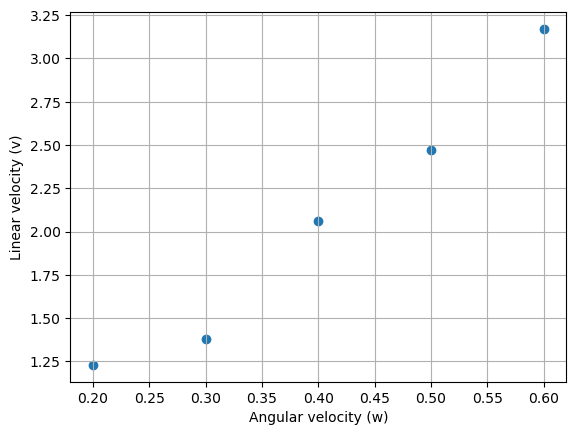

In [ ]:
plt.scatter(np.asarray(w), np.asarray(v))

plt.xlabel('Angular velocity (w)')
plt.ylabel('Linear velocity (v)')
plt.grid(True)
plt.show()

## Part 1: Parameter Value Estimation with all given measurments
----
Let's try to estimate the slope parameter $R$ using the least squares method:

\begin{align}
\hat{R} = \left(\mathbf{H}^T\mathbf{H}\right)^{-1}\mathbf{H}^T\mathbf{y}
\end{align}

If we know that we are looking for the slope parameter $R$, how do we define a matrix $\mathbf{H}$ and vector $\mathbf{y}$?

In [ ]:

# Define the H matrix, what does it contain?
H = np.ones(len(w)).reshape(len(w), 1)
H_transp = H.reshape(1, len(w))
R_vect = v / w
# Now estimate the resistance parameter.
# R = ...
R = float(np.dot(inv(np.dot(H_transp, H)),np.dot(H_transp, R_vect)))

print('The slope parameter (i.e., radius) for the best-fit line is:', R)

The slope parameter (i.e., radius) for the best-fit line is: 5.224666666666667


In [ ]:
R = np.linalg.inv(H.T@H)@H.T@R_vect


## Visualisation is really helpful

Now let's visualize our result. How do we relate our line parameter fit to the Radius value in meters?

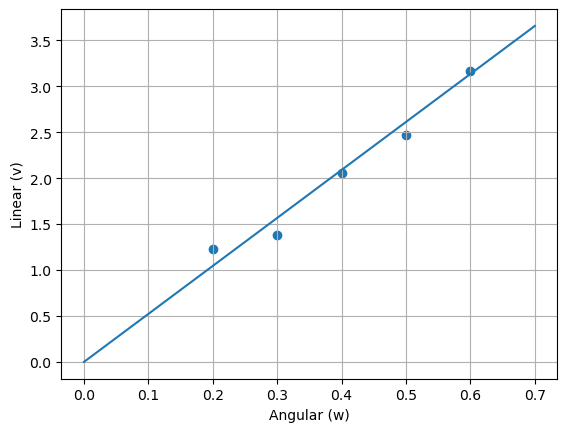

In [ ]:
w_line = np.arange(0, 0.8, 0.1)
v_line = R * w_line
plt.scatter(np.asarray(w), np.asarray(v))
plt.plot(w_line, v_line)
plt.xlabel('Angular (w)')
plt.ylabel('Linear (v)')
plt.grid(True)
plt.show()

----
## Part 2

This time you will be fitting a linear model that includes a displacement, $y = Rx + b$. ($V = RI$), we expect this offset to be near zero. Unlike the previous time, this time we will fit a model that contains the offset $y = Rx + b$. We can use the results later for comparison.

Question: What is the physical meaning of this offset? Answer: Constant part of the noise

In [ ]:
import numpy as np
from numpy import linalg
import matplotlib.pyplot as plt

w = np.array([0.2, 0.3, 0.4, 0.5, 0.6])
v = np.array([1.23, 1.38, 2.06, 2.47, 3.17])

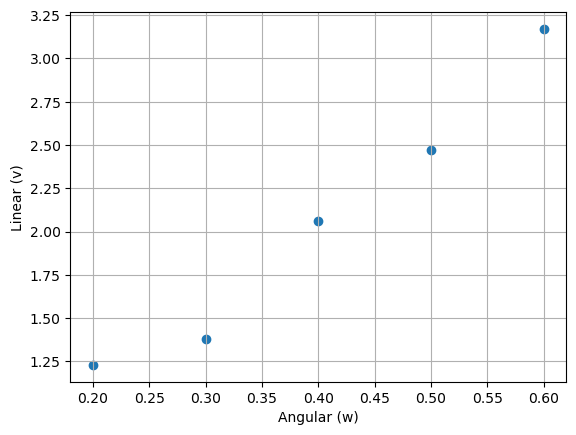

In [ ]:
#same data visualise
plt.scatter(w, v)

plt.xlabel('Angular (w)')
plt.ylabel('Linear (v)')
plt.grid(True)
plt.show()

We estimate the parameter R and b, which are now elements of the vector x (since the model is different):

$x_{ls} = (H^{T}H)^{-1}H^{T}y$

[R, b] =[0.2, 1. ], x [1.23, 1.38, 2.06, 2.47, 3.17]
        [0.3, 1. ],
        [0.4, 1. ],
        [0.5, 1. ],
        [0.6, 1. ]

In [ ]:
w

array([0.2, 0.3, 0.4, 0.5, 0.6])

Line parameters correspond ([R, b]):
[4.97  0.074]


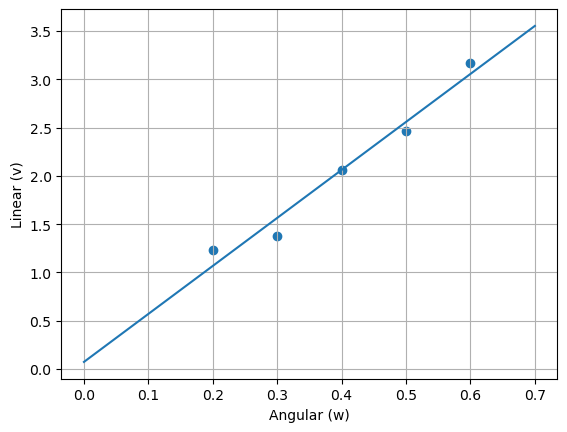

In [ ]:
## Batch Solution
H = np.ones((5,2))
H[:, 0] = w
x_ls = linalg.inv(H.T.dot(H)).dot(H.T.dot(v))

print('Line parameters correspond ([R, b]):')
print(x_ls)

#Plot
w_line = np.arange(0, 0.8, 0.1)
v_line = x_ls[0]*w_line + x_ls[1]

plt.scatter(w, v)
plt.plot(w_line, v_line)
plt.xlabel('Angular (w)')
plt.ylabel('Linear (v)')
plt.grid(True)
plt.show()

In [ ]:
# Let's take a closer look at what we have in the H matrix now.
# is it clear why exactly such a matrix is H ?
print(H)

[[0.2 1. ]
 [0.3 1. ]
 [0.4 1. ]
 [0.5 1. ]
 [0.6 1. ]]


----
## Part 3 (Task for students)

In this task, you will convert your least squares solution to a recursive one! Recall that you have the following data:

| Angular velocity (w) | Linear velocity (v) |
|-------------|-------------|
| 0.2         | 1.23        |
| 0.3         | 1.38        |
| 0.4         | 2.06        |
| 0.5         | 2.47        |
| 0.6         | 3.17        |

You will be setting the initial parameters with the assumption that your preliminary radius estimate $R = 3$, and that's a pretty rough estimate. Also, since we are reasonably sure that $v = R*w$ is true ($v = Rw$), it can be safely assumed that the displacement $b$ will be close to 0. Initialize the evaluation like this:

$$\hat{R} \sim \mathcal{N}(3, 10.0), \hat{b} \sim \mathcal{N}(0, 0.2)$$

It can be assumed that we know the linear velocity perfectly, and that the angular velocity measurements are distorted by additive, independent, and equally distributed Gaussian noise with variance $0.0225 ~ v^2$.


As before, load the linear and angular velocity measurements into separate arrays and output the values:

In [45]:
import numpy as np
from numpy import linalg
import matplotlib.pyplot as plt

v = np.array([0.2, 0.3, 0.4, 0.5, 0.6])
w = np.array([1.23, 1.38, 2.06, 2.47, 3.17])

### Recursive estimator
Now try to recursively implement the least squares method:

**Initialize Parameter and Covariance Estimates**:


$$
\hat{\mathbf{x}}_0 = E\left[\mathbf{x}\right] \,\,\, , \,\,\, \mathbf{P}_0 = E\left[(\mathbf{x} - \hat{\mathbf{x}}_0)(\mathbf{x} - \hat{\mathbf{x}}_0)^T\right]
$$


In [46]:
## Recursive solution initialization  (Perhaps not properly DONE!!!! CHECK!!!)

P_k = np.zeros((2, 2), float)
presicion = np.array([10**2, 10**2]) # Variance for R and b
np.fill_diagonal(P_k, presicion)

#Initialize parameter evaluation x
x_k = np.array([3, 0]) # Initial estimate: R = 3, b = 0

#measurement deviation (used for R_k)
v_k = 0.0225 #simga # Measurement noise variance

#save historical data for visualization at the end of the work
num_meas = v.shape[0]
x_hist = np.zeros((num_meas + 1,2))
P_hist = np.zeros((num_meas + 1,2,2))

#write down the primary values
x_hist[0] = x_k
P_hist[0] = P_k

print("x_k=", x_k)
print("P_k=", P_k)
print("num_meas=", num_meas)

x_k= [3 0]
P_k= [[100.   0.]
 [  0. 100.]]
num_meas= 5


**For each measurement k**:

----
  * Calculate correction gain $$\mathbf{K}_k = \mathbf{P}_{k-1}\mathbf{H}_k^T\left(\mathbf{H}_k\mathbf{P}_{k-1}\mathbf{H}_k^T + \mathbf{R}_k\right)^{-1}$$
  * Update Parameter Estimation $$\hat{\mathbf{x}}_k = \hat{\mathbf{x}}_{k-1} + \mathbf{K}_k\left(\mathbf{y}_k - \mathbf{H}_k\hat{\mathbf{x}}_{k-1}\right)$$
  * Update Estimated Covariance $$\mathbf{P}_k = \left(\mathbf{I} - \mathbf{K}_k\mathbf{H}_k\right)\mathbf{P}_{k-1}$$

In [47]:
# Initialization
P_k = np.zeros((2, 2), float)
precision = np.array([10**2, 0.2**2])  # Variance for R and b
np.fill_diagonal(P_k, precision)

x_k = np.array([3, 0])  # Initial estimate: R = 3, b = 0
v_k = 0.0225  # Measurement noise variance

num_meas = v.shape[0]
x_hist = np.zeros((num_meas + 1, 2))
P_hist = np.zeros((num_meas + 1, 2, 2))
x_hist[0] = x_k
P_hist[0] = P_k

# Recursive estimation
for k in range(num_meas):
    # H_k is measurement matrix for this step
    H_k = np.array([[v[k], 1.0]])  # 1x2

    # Measurement
    y_k = w[k]

    # Compute residual covariance
    S_k = H_k @ P_k @ H_k.T + v_k

    # Kalman gain
    K_k = P_k @ H_k.T @ np.linalg.inv(S_k)  # 2x1

    # Update estimate
    x_k = x_k + (K_k) @ (y_k - (H_k @ x_k))

    # Update covariance
    P_k = (np.eye(2) - K_k @ H_k) @ P_k

    # Store
    x_hist[k + 1] = x_k
    P_hist[k + 1] = P_k

# Final best estimation
print("The best estimation:")
print("R (slope) =", x_k[0], "meters")
print("b (offset) =", x_k[1])

The best estimation:
R (slope) = 5.050182924654272 meters
b (offset) = 0.037687038326554304


## Visualization of results
----
Let's draw the results of the solution at each step. Does the value converge to the "batch" least squares solution from the previous block?

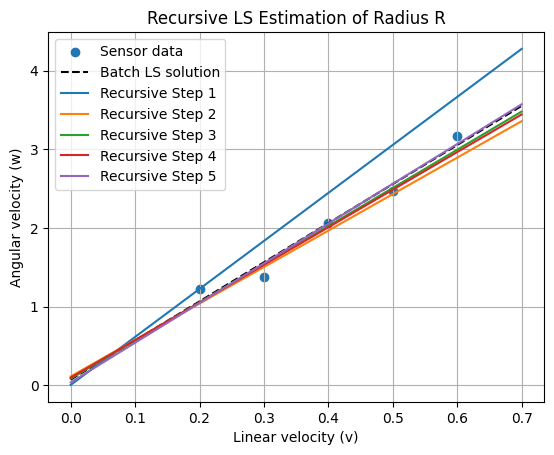

In [48]:
# Plotting
plt.scatter(v, w, label='Sensor data')

# Batch least squares for comparison
A = np.vstack([v, np.ones(len(v))]).T
x_batch, _, _, _ = np.linalg.lstsq(A, w, rcond=None)
w_line = np.arange(0, 0.8, 0.1)
v_line_batch = x_batch[0] * w_line + x_batch[1]
plt.plot(w_line, v_line_batch, label='Batch LS solution', color='black', linestyle='--')

# Plot each recursive step
for k in range(1, num_meas + 1):
    v_line = x_hist[k, 0] * w_line + x_hist[k, 1]
    plt.plot(w_line, v_line, label='Recursive Step {}'.format(k))

plt.xlabel('Linear velocity (v)')
plt.ylabel('Angular velocity (w)')
plt.title('Recursive LS Estimation of Radius R')
plt.grid(True)
plt.legend()
plt.show()